# 02 - Preprocessing and Filtering Kingshot Reviews

This notebook cleans the raw Kingshot review dataset and creates a binary sentiment label.

Labeling scheme:

```text
rating 1-2 = negative
rating 3   = removed
rating 4-5 = positive
```

Input:

```text
data/raw/kingshot_reviews_raw.csv
```

Outputs:

```text
data/processed/kingshot_reviews_processed.csv
data/processed/kingshot_reviews_processed.xlsx
outputs/tables/data_filtering_summary.xlsx
outputs/figures/rating_distribution.png
outputs/figures/sentiment_distribution.png
outputs/figures/language_distribution.png
```

The filtering process removes empty reviews, duplicated records, non-English content, low-quality text, and neutral ratings. This produces a cleaner dataset for binary sentiment classification.


## 1. Import Libraries and Define Configuration

In [1]:
from pathlib import Path
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

warnings.filterwarnings("ignore")
DetectorFactory.seed = 42

APP_NAME = "kingshot"

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() in ["notebook", "notebooks"]:
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
TABLE_DIR = BASE_DIR / "outputs" / "tables"
FIGURE_DIR = BASE_DIR / "outputs" / "figures"

for folder in [PROCESSED_DIR, TABLE_DIR, FIGURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 100)

print("CURRENT_DIR  :", CURRENT_DIR)
print("BASE_DIR     :", BASE_DIR)
print("RAW_DIR      :", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("TABLE_DIR    :", TABLE_DIR)
print("FIGURE_DIR   :", FIGURE_DIR)


CURRENT_DIR  : d:\Github\kingshot-review-sentiment-analysis\notebook
BASE_DIR     : d:\Github\kingshot-review-sentiment-analysis
RAW_DIR      : d:\Github\kingshot-review-sentiment-analysis\data\raw
PROCESSED_DIR: d:\Github\kingshot-review-sentiment-analysis\data\processed
TABLE_DIR    : d:\Github\kingshot-review-sentiment-analysis\outputs\tables
FIGURE_DIR   : d:\Github\kingshot-review-sentiment-analysis\outputs\figures


## 2. Load Raw Dataset

The raw dataset is generated by Notebook 01. The notebook stops with a clear error message if the raw file is not available.


In [2]:
raw_file = RAW_DIR / f"{APP_NAME}_reviews_raw.csv"

if not raw_file.exists():
    raise FileNotFoundError(
        f"File not found: {raw_file}\n"
        "Run Notebook 01 first."
    )

raw_df = pd.read_csv(raw_file)

print("Raw data shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.columns)


Raw data shape: (14600, 11)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,4a782aca-25f9-4fcc-8909-085c56309635,Matt,https://play-lh.googleusercontent.com/a/ACg8ocLluW4ncgy-mGrFDpCYnjaPO1AsFl2ctF05yL7yEhx4g6OK5A=mo,once again the game is nothing like the ads!! so dumb,1,0,1.10.7,2026-06-09 06:12:39,NaN,NaN,1.10.7
1,00341945-4e30-4cb6-aecd-c450bc1c1ac4,Ryo Imaizumi,https://play-lh.googleusercontent.com/a/ACg8ocJOnLkr67iwzpy8JO3SaYwomNYASQ4WxXz4xLP-AICgqAWyxg=mo,"if you are familiar with rise of kingdoms or the mobile age of empires game it's similar to that, very pay 2 win, if you are free to play, you will have no shot and will essentially be fodder. obv...",1,0,NaN,2026-06-09 05:44:24,NaN,NaN,NaN
2,7d18e706-6f87-47df-b757-49d1a8f14926,Declan Chapman,https://play-lh.googleusercontent.com/a-/ALV-UjVbIlVZTVqS9PjoRkZXaiEVIOStIFZ6_VwtHdnFhwlrC0L9ucnh,This game has the most intrusive ads that force you to this page to download it,1,0,NaN,2026-06-09 04:25:24,NaN,NaN,NaN
3,dd5afbde-4248-4867-ac93-37ec98bb3c0c,Joseph Culwell,https://play-lh.googleusercontent.com/a-/ALV-UjUSZ-MhS1LSrEg9997tISrQ2r3gOgQLCXdkPJ0t55pWAP3ldRb2Gw,this game is NOTHING like the ads. this company and the thirsty influencers need to be held accountable. this is basically a multi player castle and unit game that will require money to be competi...,1,0,1.10.7,2026-06-09 04:01:40,NaN,NaN,1.10.7
4,8adbbf7f-3b18-401e-9212-da8baee42733,Pool Gaming,https://play-lh.googleusercontent.com/a/ACg8ocI1n-zh28go1LvEAnpTr0sTmnlvg5OEWeKRblM07x2oAplzTQ=mo,is game ke bohat add ate Hein bekar gatia game poor 💩🤬😡,1,0,1.10.7,2026-06-09 03:43:07,NaN,NaN,1.10.7


Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='str')

## 3. Standardize Column Names

Google Play review fields are renamed into consistent snake_case column names to simplify downstream processing.


In [3]:
df = raw_df.copy()

rename_map = {
    "reviewId": "review_id",
    "userName": "user_name",
    "content": "review_text",
    "score": "rating",
    "thumbsUpCount": "thumbs_up",
    "reviewCreatedVersion": "app_version",
    "at": "review_date",
    "replyContent": "reply_content",
    "repliedAt": "replied_at"
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

required_columns = ["review_text", "rating"]

missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing}")

# Pastikan kolom opsional tetap ada
optional_columns = [
    "review_id", "user_name", "thumbs_up", "app_version",
    "review_date", "reply_content", "replied_at"
]

for col in optional_columns:
    if col not in df.columns:
        df[col] = None

selected_columns = [
    "review_id", "user_name", "review_text", "rating",
    "thumbs_up", "app_version", "review_date",
    "reply_content", "replied_at"
]

df = df[selected_columns].copy()

print("Data shape after standardization:", df.shape)
display(df.head())


Data shape after standardization: (14600, 9)


,review_id,user_name,review_text,rating,thumbs_up,app_version,review_date,reply_content,replied_at
0,4a782aca-25f9-4fcc-8909-085c56309635,Matt,once again the game is nothing like the ads!! so dumb,1,0,1.10.7,2026-06-09 06:12:39,NaN,NaN
1,00341945-4e30-4cb6-aecd-c450bc1c1ac4,Ryo Imaizumi,"if you are familiar with rise of kingdoms or the mobile age of empires game it's similar to that, very pay 2 win, if you are free to play, you will have no shot and will essentially be fodder. obv...",1,0,NaN,2026-06-09 05:44:24,NaN,NaN
2,7d18e706-6f87-47df-b757-49d1a8f14926,Declan Chapman,This game has the most intrusive ads that force you to this page to download it,1,0,NaN,2026-06-09 04:25:24,NaN,NaN
3,dd5afbde-4248-4867-ac93-37ec98bb3c0c,Joseph Culwell,this game is NOTHING like the ads. this company and the thirsty influencers need to be held accountable. this is basically a multi player castle and unit game that will require money to be competi...,1,0,1.10.7,2026-06-09 04:01:40,NaN,NaN
4,8adbbf7f-3b18-401e-9212-da8baee42733,Pool Gaming,is game ke bohat add ate Hein bekar gatia game poor 💩🤬😡,1,0,1.10.7,2026-06-09 03:43:07,NaN,NaN


## 4. Define Text Cleaning Functions

This section defines helper functions for emoji removal, text normalization, language detection, and low-quality review filtering.


In [4]:
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

def count_emoji(text):
    text = str(text)
    return len(emoji_pattern.findall(text))

def remove_emoji(text):
    return emoji_pattern.sub(" ", str(text))

def clean_text(text):
    text = str(text).lower()
    text = remove_emoji(text)

    # hapus URL, email, dan karakter HTML sederhana
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"&\w+;", " ", text)

    # normalisasi apostrophe umum
    text = text.replace("can't", "cant")
    text = text.replace("don't", "dont")
    text = text.replace("doesn't", "doesnt")
    text = text.replace("didn't", "didnt")
    text = text.replace("isn't", "isnt")
    text = text.replace("wasn't", "wasnt")
    text = text.replace("won't", "wont")

    # sisakan huruf, angka, dan spasi
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # rapikan spasi
    text = re.sub(r"\s+", " ", text).strip()

    return text

def detect_language_safe(text):
    text = str(text).strip()
    if not text or len(text.split()) < 3:
        return "unknown"

    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

def is_low_quality_text(text):
    text = str(text).strip()

    if not text:
        return True

    words = text.split()

    # terlalu pendek
    if len(words) < 3:
        return True

    # karakter unik terlalu sedikit
    if len(set(text.replace(" ", ""))) <= 2:
        return True

    # mayoritas token satu karakter
    one_char_ratio = sum(1 for w in words if len(w) == 1) / max(len(words), 1)
    if one_char_ratio > 0.6:
        return True

    return False


## 5. Apply Preprocessing and Filtering

The preprocessing pipeline applies the following steps:

1. Remove empty review text and missing ratings.
2. Convert ratings into numeric values.
3. Remove duplicated reviews.
4. Remove emojis and normalize text.
5. Detect review language and keep English reviews only.
6. Remove low-quality review text.
7. Remove neutral ratings.
8. Create a binary sentiment label.


In [5]:
summary_rows = []

def add_summary(step, data):
    summary_rows.append({
        "step": step,
        "rows": len(data)
    })

add_summary("raw_data", df)

# Remove empty reviews
df = df.dropna(subset=["review_text", "rating"]).copy()
df["review_text"] = df["review_text"].astype(str)
add_summary("drop_empty_review_and_rating", df)

# Convert ratings
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["rating"]).copy()
df["rating"] = df["rating"].astype(int)
add_summary("valid_rating", df)

# Remove duplicates
if df["review_id"].notna().any():
    df = df.drop_duplicates(subset=["review_id"]).copy()
else:
    df = df.drop_duplicates(subset=["review_text", "rating"]).copy()

# Store emoji information
df["emoji_count"] = df["review_text"].apply(count_emoji)
df["has_emoji"] = df["emoji_count"] > 0

# Text cleaning
df["clean_text"] = df["review_text"].apply(clean_text)
df["word_count"] = df["clean_text"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["clean_text"].apply(lambda x: len(str(x)))

# Remove empty cleaned text
df = df[df["clean_text"].str.strip() != ""].copy()
add_summary("drop_empty_clean_text", df)

# Detect language
df["language"] = df["clean_text"].apply(detect_language_safe)
add_summary("language_detection", df)

# Keep English reviews only
df = df[df["language"] == "en"].copy()
add_summary("keep_english_only", df)

# Remove low-quality text
df["is_low_quality"] = df["clean_text"].apply(is_low_quality_text)
df = df[df["is_low_quality"] == False].copy()
add_summary("drop_low_quality_text", df)

# Remove neutral rating
df = df[df["rating"] != 3].copy()
add_summary("drop_rating_3_neutral", df)

# Create binary sentiment label
df["sentiment"] = np.where(df["rating"] <= 2, "negative", "positive")
add_summary("binary_sentiment_data", df)

df = df.reset_index(drop=True)

summary_df = pd.DataFrame(summary_rows)

display(summary_df)
display(df.head())
display(df["sentiment"].value_counts())
display(df["rating"].value_counts().sort_index())


,step,rows
0,raw_data,14600
1,drop_empty_review_and_rating,14599
2,valid_rating,14599
3,drop_empty_clean_text,14419
4,language_detection,14419
5,keep_english_only,10215
6,drop_low_quality_text,10214
7,drop_rating_3_neutral,9640
8,binary_sentiment_data,9640


,review_id,user_name,review_text,rating,thumbs_up,app_version,review_date,reply_content,replied_at,emoji_count,has_emoji,clean_text,word_count,char_count,language,is_low_quality,sentiment
0,4a782aca-25f9-4fcc-8909-085c56309635,Matt,once again the game is nothing like the ads!! so dumb,1,0,1.10.7,2026-06-09 06:12:39,NaN,NaN,0,False,once again the game is nothing like the ads so dumb,11,51,en,False,negative
1,00341945-4e30-4cb6-aecd-c450bc1c1ac4,Ryo Imaizumi,"if you are familiar with rise of kingdoms or the mobile age of empires game it's similar to that, very pay 2 win, if you are free to play, you will have no shot and will essentially be fodder. obv...",1,0,NaN,2026-06-09 05:44:24,NaN,NaN,0,False,if you are familiar with rise of kingdoms or the mobile age of empires game it s similar to that very pay 2 win if you are free to play you will have no shot and will essentially be fodder obvious...,66,325,en,False,negative
2,7d18e706-6f87-47df-b757-49d1a8f14926,Declan Chapman,This game has the most intrusive ads that force you to this page to download it,1,0,NaN,2026-06-09 04:25:24,NaN,NaN,0,False,this game has the most intrusive ads that force you to this page to download it,16,79,en,False,negative
3,dd5afbde-4248-4867-ac93-37ec98bb3c0c,Joseph Culwell,this game is NOTHING like the ads. this company and the thirsty influencers need to be held accountable. this is basically a multi player castle and unit game that will require money to be competi...,1,0,1.10.7,2026-06-09 04:01:40,NaN,NaN,0,False,this game is nothing like the ads this company and the thirsty influencers need to be held accountable this is basically a multi player castle and unit game that will require money to be competiti...,39,225,en,False,negative
4,2a435332-b1ab-45cd-b453-6baa0a6f87f9,Matthew Banda,"games actually not bad, has a whole story line. thought it was some dumb ad that kept popping up. it's not though pretty addictive game.",5,0,1.10.7,2026-06-09 03:33:48,NaN,NaN,0,False,games actually not bad has a whole story line thought it was some dumb ad that kept popping up it s not though pretty addictive game,26,132,en,False,positive


sentiment
negative    6243
positive    3397
Name: count, dtype: int64

rating
1    5510
2     733
4     733
5    2664
Name: count, dtype: int64

## 6. Visualize Filtered Data Distribution

The figures below summarize the filtered dataset and are saved for reporting.


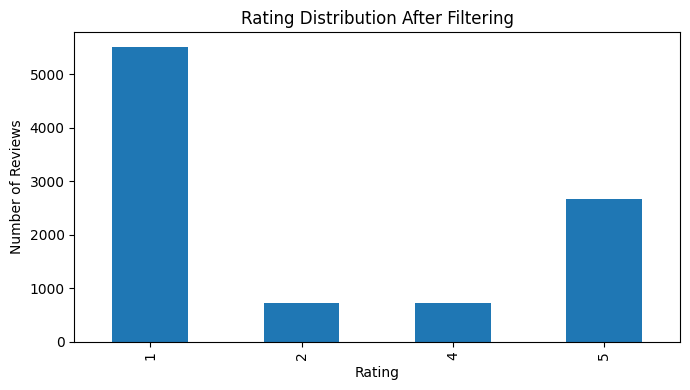

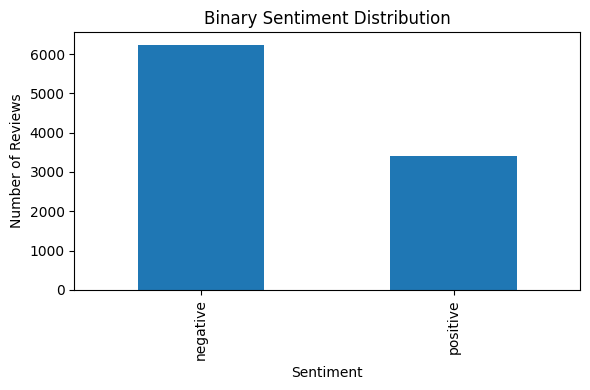

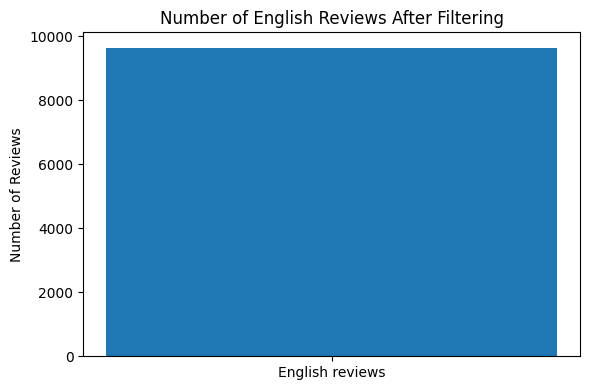

In [6]:
plt.figure(figsize=(7, 4))
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution After Filtering")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "rating_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Binary Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "sentiment_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
raw_lang_counts = raw_df.rename(columns={"content": "review_text"}).copy()
plt.bar(["English reviews"], [len(df)])
plt.title("Number of English Reviews After Filtering")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "language_distribution.png", dpi=300)
plt.show()


## 7. Save Processed Dataset

The processed dataset and the filtering summary are saved in CSV, Excel, and table formats for later notebooks.


In [7]:
processed_csv = PROCESSED_DIR / f"{APP_NAME}_reviews_processed.csv"
processed_xlsx = PROCESSED_DIR / f"{APP_NAME}_reviews_processed.xlsx"
summary_file = TABLE_DIR / "data_filtering_summary.xlsx"

df.to_csv(processed_csv, index=False, encoding="utf-8-sig")
df.to_excel(processed_xlsx, index=False)
summary_df.to_excel(summary_file, index=False)

print(f"Processed CSV saved to   : {processed_csv}")
print(f"Processed Excel saved to : {processed_xlsx}")
print(f"Filtering summary        : {summary_file}")


Processed CSV saved to   : d:\Github\kingshot-review-sentiment-analysis\data\processed\kingshot_reviews_processed.csv
Processed Excel saved to : d:\Github\kingshot-review-sentiment-analysis\data\processed\kingshot_reviews_processed.xlsx
Filtering summary        : d:\Github\kingshot-review-sentiment-analysis\outputs\tables\data_filtering_summary.xlsx


## Notes

```text
The review dataset was cleaned by removing empty records, duplicated entries, non-English reviews, low-quality text, and neutral ratings. Ratings 1-2 were labeled as negative, while ratings 4-5 were labeled as positive. Rating 3 was excluded because it represents a neutral or ambiguous sentiment in binary classification.
```
